# 02 — Forecast projection (real-data marketing-lift)

Take the cleaned weekly CSV from `01_signal_extraction.ipynb`, interpolate to daily, anchor at the 2026-04-06 campaign launch, run A/B/C validation against the April mktg-off forecast + June actuals, and export a `.parquet` + `.meta.json` artifact that the production `m` adjustment can consume unchanged.

Mirrors the validation framework in `.claude/worktrees/marketing-lift/marketing_lift_model/03_forecast_projection.ipynb`. **Key structural difference:** no SCALE_FACTOR fit — the CSV provides a direct lift signal, so Validation A is a genuine independent check rather than passing by construction.


In [1]:
# [setup]
import hashlib
import json
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths
WEEKLY_PARQUET = Path('data/weekly_paid_dau_clean.parquet')
SOURCE_CSV = Path('data/paid_dau_weekly_forecast.20260519.csv')
OUT_PARQUET = Path('data/marketing_lift_model.real_data.2026-05-19.parquet')
OUT_META = Path('data/marketing_lift_model.real_data.2026-05-19.meta.json')
EXISTING_CONVOLUTION_PARQUET = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/marketing/'
    'marketing_lift_model.2026-05-16.parquet'
)

# Forecasts used for A/B/C validation (mobile rollup, ex-Iran via filter, ALL country / ALL MOBILE app)
APRIL_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/'
    'mobile_cps0.02_thresh32_recent13_clip0.6/'
    'mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
)
JUNE_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/'
    'mobile_cps0.02_thresh32_recent13_clip0.6_cap426/'
    'mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'
)

# Dates
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')
# Anchor date where lift = 0. Interim choice (2026-05-19): use the Monday
# immediately before launch — Option B "soft launch" framing from
# 03_exploration.ipynb. Closes the Fenix-gap residual from -143k to -110k.
# Pending analyst confirmation (see questions_for_marketing_analyst.md).
ANCHOR_DATE = pd.Timestamp('2026-03-30')
LAST_HISTORICAL_DATE = pd.Timestamp('2026-05-19')  # CSV generation date (from filename)
PARQUET_START = pd.Timestamp('2026-02-01')
PARQUET_END = pd.Timestamp('2026-12-31')
BASELINE_START = pd.Timestamp('2026-02-01')
BASELINE_END = pd.Timestamp('2026-03-28')
FORECAST_END = PARQUET_END

# MA window
MA_WINDOW = 28

# Easter mask — same dates as the convolution model's 03_forecast_projection.ipynb
EASTER_MASK_DATES = pd.DatetimeIndex(sorted(set(
    [pd.Timestamp('2026-04-05') + pd.Timedelta(days=d) for d in range(-2, 3)] +
    [pd.Timestamp('2026-04-18') + pd.Timedelta(days=d) for d in range(-2, 3)]
)))


In [2]:
# [load-weekly]
weekly = pd.read_parquet(WEEKLY_PARQUET).sort_values('week_starting').reset_index(drop=True)
assert (weekly['week_starting'].dt.dayofweek == 0).all()

print(f'Loaded {len(weekly)} weekly rows from {WEEKLY_PARQUET}')
print(f'Date range: {weekly["week_starting"].min().date()} → {weekly["week_starting"].max().date()}')
print()
print('Anchor week (campaign launch):')
anchor_row = weekly[weekly['week_starting'] == ANCHOR_DATE].iloc[0]
print(f'  week_starting   = {anchor_row["week_starting"].date()}')
print(f'  total_paid_dau  = {anchor_row["total_paid_dau"]:>10,}')


Loaded 52 weekly rows from data/weekly_paid_dau_clean.parquet
Date range: 2026-01-05 → 2026-12-28

Anchor week (campaign launch):
  week_starting   = 2026-03-30
  total_paid_dau  =    972,770


In [3]:
# [interpolate-daily]
# Linear interpolation between Monday anchors. Each weekly value is treated as
# the daily DAU level at that Monday (per BQ spot-check on 2026-05-19, the CSV
# value at 2026-04-06 = 1.014M matches the BQ paid-DAU daily level ~1.044M
# within ~3%, confirming the snapshot interpretation rather than weekly sum).

weekly_indexed = weekly.set_index('week_starting')['total_paid_dau'].astype('float64')

daily_index = pd.date_range(weekly_indexed.index.min(), weekly_indexed.index.max(), freq='D')
daily_paid = weekly_indexed.reindex(daily_index).interpolate(method='linear', limit_area='inside')

# Forward-fill the 3 trailing days after the last Monday (2026-12-28 → 2026-12-31).
print('Daily series before forward-fill check:')
print(f'  index range: {daily_paid.index.min().date()} → {daily_paid.index.max().date()}')
print(f'  NaN count:   {daily_paid.isna().sum()}')

extended_index = pd.date_range(daily_paid.index.min(), PARQUET_END, freq='D')
daily_paid = daily_paid.reindex(extended_index).ffill()
print()
print(f'After forward-fill to {PARQUET_END.date()}:')
print(f'  index range: {daily_paid.index.min().date()} → {daily_paid.index.max().date()}')
print(f'  NaN count:   {daily_paid.isna().sum()}')


Daily series before forward-fill check:
  index range: 2026-01-05 → 2026-12-28
  NaN count:   0

After forward-fill to 2026-12-31:
  index range: 2026-01-05 → 2026-12-31
  NaN count:   0


In [4]:
# [anchor-at-launch]
# Subtract paid DAU at the anchor date; pre-launch values clipped to 0
# (the campaign hadn't started yet, so lift is definitionally zero, not negative).

anchor_value = float(daily_paid.loc[ANCHOR_DATE])
lift_raw = daily_paid - anchor_value
marketing_lift_daily = lift_raw.where(lift_raw.index >= ANCHOR_DATE, 0.0).copy()
marketing_lift_daily.name = 'marketing_lift_daily'

print(f'Anchor value (total_paid_dau at {ANCHOR_DATE.date()}): {anchor_value:>14,.0f}')
print()
print('Marketing lift snapshot (post-anchor, daily values):')
print(f'  {"date":>10}  {"lift_daily":>14}')
for d in [pd.Timestamp('2026-03-01'),  # pre-launch (should be 0)
          pd.Timestamp('2026-04-05'),  # day before launch (should be 0)
          ANCHOR_DATE,
          pd.Timestamp('2026-05-01'),
          LAST_HISTORICAL_DATE,
          pd.Timestamp('2026-07-01'),
          pd.Timestamp('2026-09-01'),
          pd.Timestamp('2026-12-15'),
          PARQUET_END]:
    if d in marketing_lift_daily.index:
        val = marketing_lift_daily.loc[d]
        print(f'  {d.date()}  {val:>+14,.0f}')

assert marketing_lift_daily.loc[ANCHOR_DATE] == 0.0, 'lift at anchor must be exactly 0'
assert (marketing_lift_daily.loc[:ANCHOR_DATE - pd.Timedelta(days=1)] == 0.0).all(), \
    'all pre-launch lift must be 0'


Anchor value (total_paid_dau at 2026-03-30):        972,770

Marketing lift snapshot (post-anchor, daily values):
        date      lift_daily
  2026-03-01              +0
  2026-04-05         +35,653
  2026-03-30              +0
  2026-05-01        +196,934
  2026-05-19        +174,998
  2026-07-01        +410,940
  2026-09-01        +406,362
  2026-12-15        +490,063
  2026-12-31        +501,073


In [5]:
# [pad-to-coverage]
# Extend backward to PARQUET_START (2026-02-01). Days before the CSV's first
# Monday (2026-01-05) are pre-launch and get 0.

full_index = pd.date_range(PARQUET_START, PARQUET_END, freq='D')
marketing_lift_daily = marketing_lift_daily.reindex(full_index, fill_value=0.0)
marketing_lift_daily.name = 'marketing_lift_daily'

assert marketing_lift_daily.isna().sum() == 0, 'no NaN allowed in final daily series'
assert marketing_lift_daily.index.min() == PARQUET_START
assert marketing_lift_daily.index.max() == PARQUET_END

print(f'Daily lift series coverage: {marketing_lift_daily.index.min().date()} → {marketing_lift_daily.index.max().date()}')
print(f'Rows: {len(marketing_lift_daily)}  (expected: 334)')
print(f'NaN: {marketing_lift_daily.isna().sum()}')
print(f'Pre-launch (2026-02-01 → 2026-04-05) is exactly 0: {(marketing_lift_daily.loc[:ANCHOR_DATE - pd.Timedelta(days=1)] == 0.0).all()}')


Daily lift series coverage: 2026-02-01 → 2026-12-31
Rows: 334  (expected: 334)
NaN: 0
Pre-launch (2026-02-01 → 2026-04-05) is exactly 0: True


In [6]:
# [compute-ma]
marketing_lift_ma = (marketing_lift_daily
                     .rolling(window=MA_WINDOW, min_periods=14)
                     .mean()
                     .rename('marketing_lift_ma'))

print(f'MA28 series coverage: {marketing_lift_ma.index.min().date()} → {marketing_lift_ma.index.max().date()}')
print(f'First non-NaN: {marketing_lift_ma.first_valid_index().date()}  '
      f'(expected: 13 days after PARQUET_START)')
print()
print('MA28 snapshot:')
print(f'  {"date":>10}  {"daily":>14}  {"ma28":>14}')
for d in [ANCHOR_DATE,
          pd.Timestamp('2026-05-01'),
          LAST_HISTORICAL_DATE,
          pd.Timestamp('2026-07-01'),
          pd.Timestamp('2026-09-01'),
          pd.Timestamp('2026-12-15'),
          PARQUET_END]:
    daily_val = marketing_lift_daily.loc[d]
    ma_val = marketing_lift_ma.loc[d]
    daily_str = f'{daily_val:>+14,.0f}'
    ma_str = f'{ma_val:>+14,.0f}' if pd.notna(ma_val) else f'{"NaN":>14}'
    print(f'  {d.date()}  {daily_str}  {ma_str}')


MA28 series coverage: 2026-02-01 → 2026-12-31
First non-NaN: 2026-02-14  (expected: 13 days after PARQUET_START)

MA28 snapshot:
        date           daily            ma28
  2026-03-30              +0              +0
  2026-05-01        +196,934        +118,569
  2026-05-19        +174,998        +212,805
  2026-07-01        +410,940        +436,924
  2026-09-01        +406,362        +399,168
  2026-12-15        +490,063        +478,609
  2026-12-31        +501,073        +491,996


In [7]:
# [load-forecasts-and-actuals]
# Mobile rollup helper — copied verbatim from
# `.claude/worktrees/marketing-lift/marketing_lift_model/03_forecast_projection.ipynb:[scaled-fenix-model]`.

def _mobile_total(path, data_type_filter=None):
    df = pd.read_parquet(path)
    rollup = df[(df['data_source'] == 'glean_mobile')
                & (df['country'] == 'ALL')
                & (df['app_name'] == 'ALL MOBILE')
                & (df['segment'] == '{}')].copy()
    if data_type_filter is not None:
        rollup = rollup[rollup['data_type'] == data_type_filter]
    rollup['target_date'] = pd.to_datetime(rollup['target_date'])
    return rollup.set_index('target_date').sort_index()['dau']


april_full_mobile = _mobile_total(APRIL_FORECAST_PATH)
actuals_mobile = _mobile_total(JUNE_FORECAST_PATH, data_type_filter='training')

gap_index = april_full_mobile.index.intersection(actuals_mobile.index)
gap_daily = (actuals_mobile.reindex(gap_index)
             - april_full_mobile.reindex(gap_index)).rename('gap_daily')
gap_ma = gap_daily.rolling(window=MA_WINDOW, min_periods=14).mean().rename('gap_ma')

actuals_ma = actuals_mobile.rolling(window=MA_WINDOW, min_periods=14).mean().rename('actuals_ma')
april_ma = april_full_mobile.rolling(window=MA_WINDOW, min_periods=14).mean().rename('april_ma')

print(f'April forecast (mktg-off) rollup: {len(april_full_mobile):>5} rows, '
      f'{april_full_mobile.index.min().date()} → {april_full_mobile.index.max().date()}')
print(f'June actuals (training rows):     {len(actuals_mobile):>5} rows, '
      f'{actuals_mobile.index.min().date()} → {actuals_mobile.index.max().date()}')
print(f'Overlap (gap):                    {len(gap_index):>5} days, '
      f'{gap_index.min().date()} → {gap_index.max().date()}')


April forecast (mktg-off) rollup:  2557 rows, 2020-12-31 → 2027-12-31
June actuals (training rows):      1963 rows, 2020-12-31 → 2026-05-16
Overlap (gap):                     1963 days, 2020-12-31 → 2026-05-16


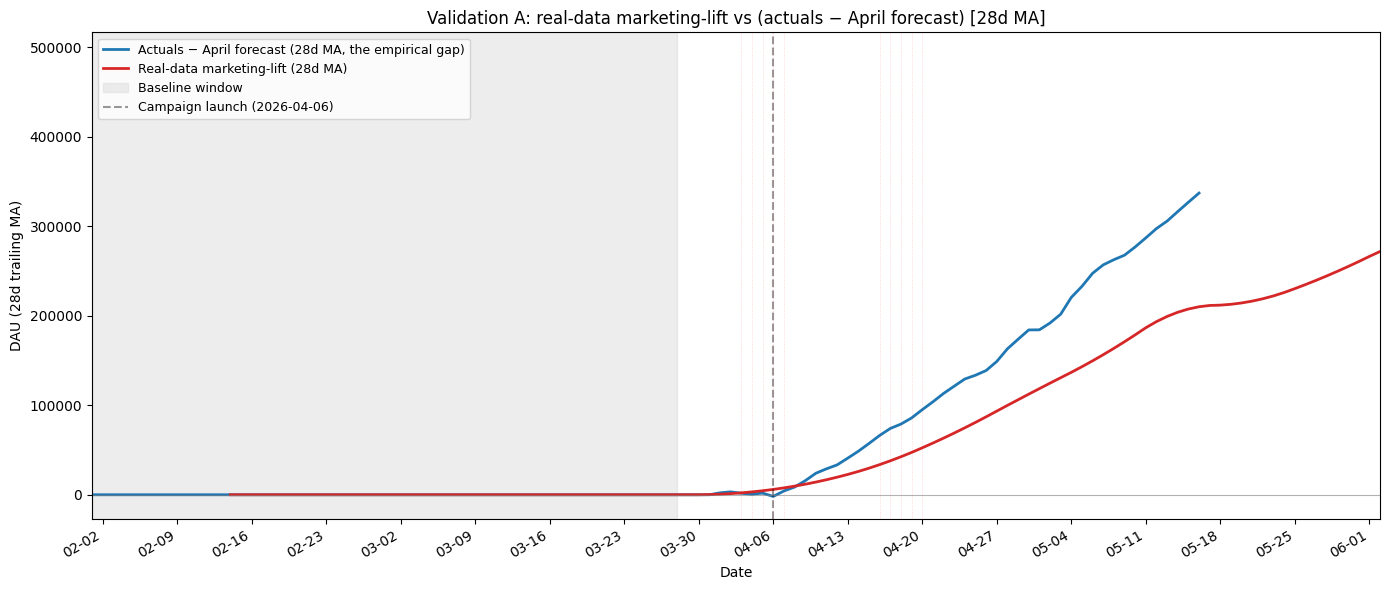

Validation A — residual (marketing_lift_ma − gap_ma), post-campaign non-Easter days:
  N days:    34
  Gap mean (post-campaign):                 +172,953 DAU
  Real-data lift mean (post-campaign):      +107,903 DAU
  Residual mean:                             -65,050 DAU  (undershoot)
  Residual std:                              +36,276 DAU
  Residual RMSE:                             +74,221 DAU


In [8]:
# [validation-a-fit]
# Validation A: does our real-data marketing_lift_ma match the empirical gap_ma
# post-campaign (non-Easter, MAs valid)? Unlike the convolution model where
# this was zero-by-construction (SCALE_FACTOR forced the means to match), here
# this is a genuine independent check.

ma_compare_index = gap_ma.index.intersection(marketing_lift_ma.index)
compare_mask = (
    (ma_compare_index >= CAMPAIGN_LAUNCH)
    & (~ma_compare_index.isin(EASTER_MASK_DATES))
    & gap_ma.reindex(ma_compare_index).notna()
    & marketing_lift_ma.reindex(ma_compare_index).notna()
)
compare_dates = ma_compare_index[compare_mask]
gap_ma_mean_post = gap_ma.reindex(compare_dates).mean()
marketing_lift_ma_mean_post = marketing_lift_ma.reindex(compare_dates).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(gap_ma.index, gap_ma, '-', linewidth=2, color='C0',
        label='Actuals − April forecast (28d MA, the empirical gap)')
ax.plot(marketing_lift_ma.index, marketing_lift_ma, '-', linewidth=2, color='C3',
        label='Real-data marketing-lift (28d MA)')

ax.axvspan(BASELINE_START, BASELINE_END, color='lightgrey', alpha=0.4,
           label='Baseline window')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4,
           label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')
for day in EASTER_MASK_DATES:
    ax.axvline(day, color='red', linestyle=':', linewidth=0.6, alpha=0.2)
ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)

ax.set_title('Validation A: real-data marketing-lift vs (actuals − April forecast) [28d MA]')
ax.set_ylabel('DAU (28d trailing MA)')
ax.set_xlabel('Date')
ax.set_xlim(BASELINE_START, LAST_HISTORICAL_DATE + pd.Timedelta(days=14))
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

a_residuals = (marketing_lift_ma - gap_ma).reindex(compare_dates)
a_residual_mean = float(a_residuals.mean())
a_residual_std = float(a_residuals.std())
a_residual_rmse = float(np.sqrt((a_residuals ** 2).mean()))

print(f'Validation A — residual (marketing_lift_ma − gap_ma), post-campaign non-Easter days:')
print(f'  N days:    {len(a_residuals)}')
print(f'  Gap mean (post-campaign):           {gap_ma_mean_post:>+14,.0f} DAU')
print(f'  Real-data lift mean (post-campaign):{marketing_lift_ma_mean_post:>+14,.0f} DAU')
print(f'  Residual mean:                      {a_residual_mean:>+14,.0f} DAU  '
      f'({"over" if a_residual_mean > 0 else "under"}shoot)')
print(f'  Residual std:                       {a_residual_std:>+14,.0f} DAU')
print(f'  Residual RMSE:                      {a_residual_rmse:>+14,.0f} DAU')


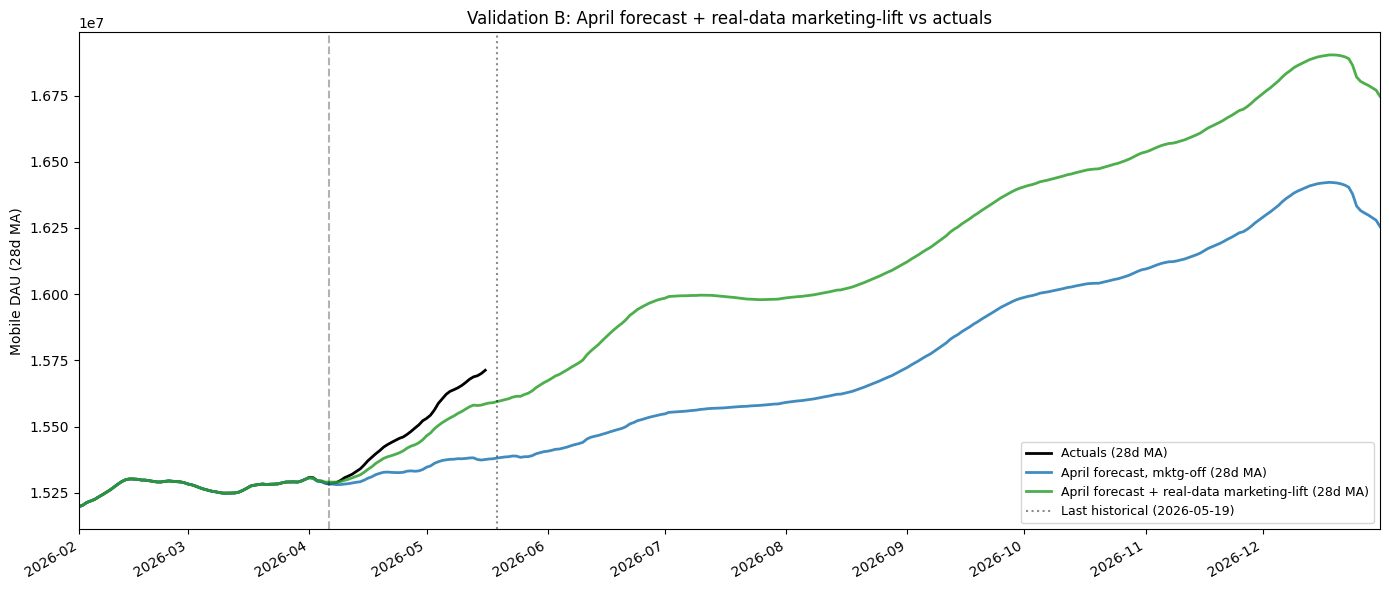

Validation B — key values (28d MA, mobile DAU):
        date         actuals           april      april+mktg
  2026-04-06     +15,282,455     +15,284,336     +15,290,278
  2026-05-01     +15,531,103     +15,346,816     +15,465,385
  2026-05-19                     +15,381,164     +15,593,969
  2026-07-01                     +15,548,035     +15,984,959
  2026-09-01                     +15,723,116     +16,122,284
  2026-12-15                     +16,416,911     +16,895,520


In [9]:
# [validation-b-overlay]
# Validation B: does (April forecast + real-data marketing-lift) overlay actuals?

PLOT_START = pd.Timestamp('2026-02-01')
PLOT_END = pd.Timestamp('2026-12-31')
plot_index = pd.date_range(PLOT_START, PLOT_END, freq='D')

actuals_ma_v = actuals_ma.reindex(plot_index)
april_ma_v = april_ma.reindex(plot_index)
marketing_ma_v = marketing_lift_ma.reindex(plot_index).fillna(0.0)
combined_ma_v = april_ma_v + marketing_ma_v

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(actuals_ma_v.index, actuals_ma_v, '-', linewidth=2, color='black',
        label='Actuals (28d MA)')
ax.plot(april_ma_v.index, april_ma_v, '-', linewidth=2, color='C0', alpha=0.85,
        label='April forecast, mktg-off (28d MA)')
ax.plot(combined_ma_v.index, combined_ma_v, '-', linewidth=2, color='C2', alpha=0.85,
        label='April forecast + real-data marketing-lift (28d MA)')

ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.3)
ax.axvline(LAST_HISTORICAL_DATE, color='black', linestyle=':', alpha=0.45,
           label=f'Last historical ({LAST_HISTORICAL_DATE.date()})')
ax.set_xlim(PLOT_START, PLOT_END)
ax.set_title('Validation B: April forecast + real-data marketing-lift vs actuals')
ax.set_ylabel('Mobile DAU (28d MA)')
ax.legend(fontsize=9, loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Snapshot values
print('Validation B — key values (28d MA, mobile DAU):')
print(f'  {"date":>10}  {"actuals":>14}  {"april":>14}  {"april+mktg":>14}')
for day in [CAMPAIGN_LAUNCH, pd.Timestamp('2026-05-01'), LAST_HISTORICAL_DATE,
            pd.Timestamp('2026-07-01'), pd.Timestamp('2026-09-01'),
            pd.Timestamp('2026-12-15')]:
    if day not in plot_index:
        continue
    a = actuals_ma_v.loc[day]
    f = april_ma_v.loc[day]
    c = combined_ma_v.loc[day]

    def _fmt(v):
        return f'{v:>+14,.0f}' if pd.notna(v) else f'{"":>14}'

    print(f'  {day.date()}  {_fmt(a)}  {_fmt(f)}  {_fmt(c)}')


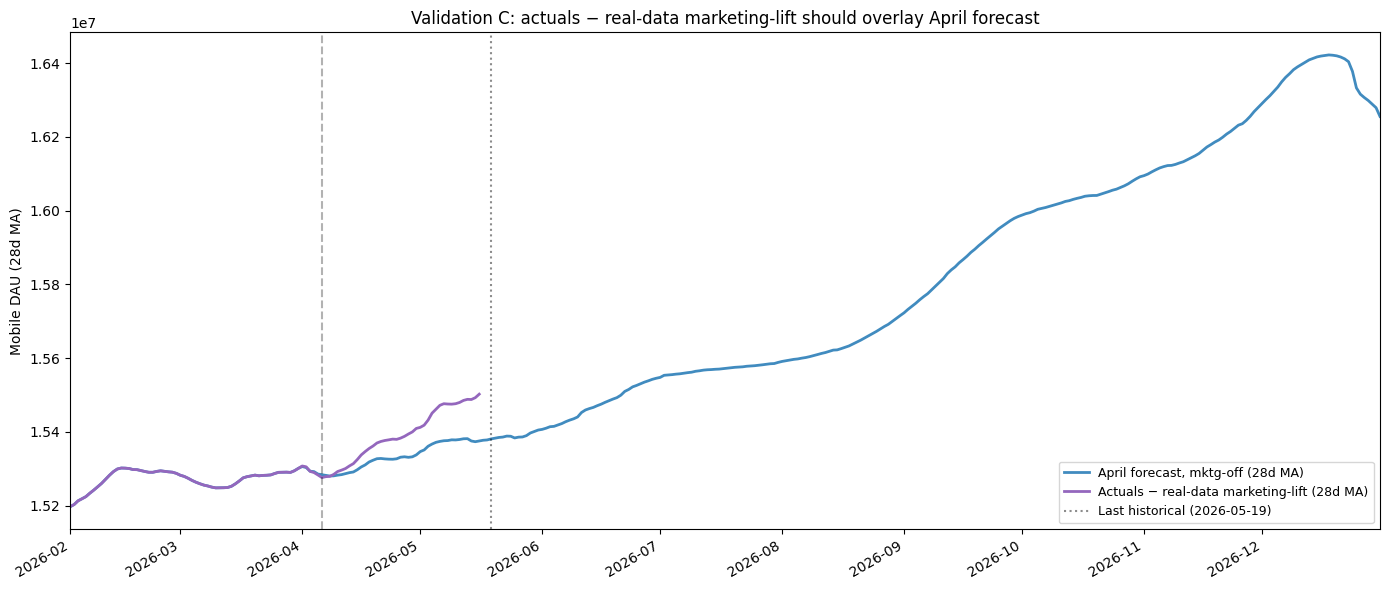

Validation C — counterfactual residual: (actuals − marketing-lift) − April forecast (28d MA)
  N days:  105
  Mean:         +22,710 DAU
  Std:          +36,722 DAU
  Min:           -7,823 DAU  (at 2026-04-06)
  Max:         +127,027 DAU  (at 2026-05-16)


In [10]:
# [validation-c-counterfactual]
# Validation C: does (actuals − real-data marketing-lift) overlay April forecast?
# This is the counterfactual: subtract the marketing effect, recover the no-marketing world.

actuals_minus_marketing_v = actuals_ma_v - marketing_ma_v

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(april_ma_v.index, april_ma_v, '-', linewidth=2, color='C0', alpha=0.85,
        label='April forecast, mktg-off (28d MA)')
have_actuals = actuals_ma_v.notna()
ax.plot(actuals_minus_marketing_v.index[have_actuals],
        actuals_minus_marketing_v[have_actuals],
        '-', linewidth=2, color='C4',
        label='Actuals − real-data marketing-lift (28d MA)')

ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.3)
ax.axvline(LAST_HISTORICAL_DATE, color='black', linestyle=':', alpha=0.45,
           label=f'Last historical ({LAST_HISTORICAL_DATE.date()})')
ax.set_xlim(PLOT_START, PLOT_END)
ax.set_title('Validation C: actuals − real-data marketing-lift should overlay April forecast')
ax.set_ylabel('Mobile DAU (28d MA)')
ax.legend(fontsize=9, loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

counterfactual_residual = (actuals_minus_marketing_v - april_ma_v).dropna()
c_resid_mean = float(counterfactual_residual.mean())
c_resid_std = float(counterfactual_residual.std())
c_resid_min = float(counterfactual_residual.min())
c_resid_max = float(counterfactual_residual.max())
c_resid_min_date = counterfactual_residual.idxmin().date()
c_resid_max_date = counterfactual_residual.idxmax().date()

print('Validation C — counterfactual residual: (actuals − marketing-lift) − April forecast (28d MA)')
print(f'  N days:  {len(counterfactual_residual)}')
print(f'  Mean:    {c_resid_mean:>+12,.0f} DAU')
print(f'  Std:     {c_resid_std:>+12,.0f} DAU')
print(f'  Min:     {c_resid_min:>+12,.0f} DAU  (at {c_resid_min_date})')
print(f'  Max:     {c_resid_max:>+12,.0f} DAU  (at {c_resid_max_date})')


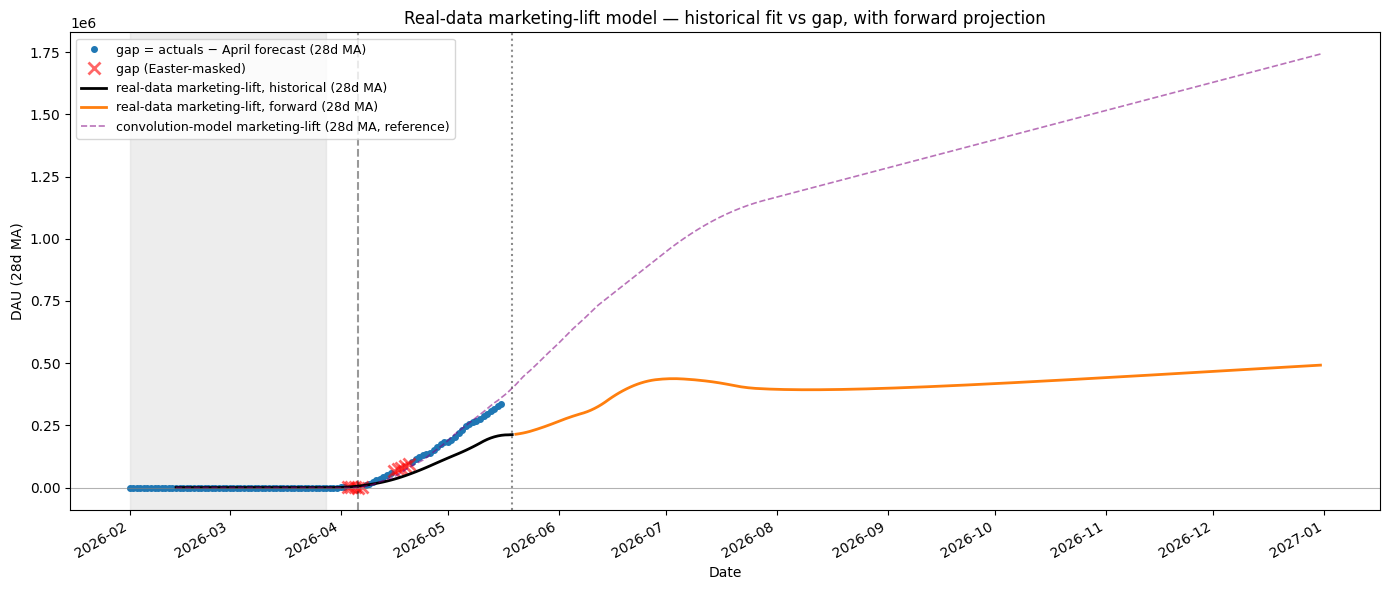

In [11]:
# [final-summary-plot]
# Summary mirroring convolution model's [plot-final-model] LEFT panel only —
# we don't have a retention kernel to show on the right.

fig, ax = plt.subplots(figsize=(14, 6))

gap_ma_plot = gap_ma.reindex(plot_index)
mktg_ma_plot = marketing_lift_ma.reindex(plot_index)

hist_mask = plot_index <= LAST_HISTORICAL_DATE
fwd_mask = plot_index > LAST_HISTORICAL_DATE
easter_in_plot = plot_index.isin(EASTER_MASK_DATES)

ax.plot(plot_index, gap_ma_plot, '-', linewidth=1.0, color='C0', alpha=0.35)
ax.plot(plot_index[~easter_in_plot], gap_ma_plot[~easter_in_plot],
        'o', markersize=4, color='C0',
        label='gap = actuals − April forecast (28d MA)')
ax.plot(plot_index[easter_in_plot], gap_ma_plot[easter_in_plot],
        'x', markersize=8, color='red', markeredgewidth=2, alpha=0.6,
        label='gap (Easter-masked)')
ax.plot(plot_index[hist_mask], mktg_ma_plot[hist_mask],
        '-', linewidth=2, color='black',
        label='real-data marketing-lift, historical (28d MA)')
ax.plot(plot_index[fwd_mask], mktg_ma_plot[fwd_mask],
        '-', linewidth=2, color='C1',
        label='real-data marketing-lift, forward (28d MA)')

# Overlay convolution model as faint reference
try:
    convolution_df = pd.read_parquet(EXISTING_CONVOLUTION_PARQUET)
    conv_ma = convolution_df['marketing_lift_ma'].reindex(plot_index)
    ax.plot(plot_index, conv_ma, '--', linewidth=1.2, color='purple', alpha=0.55,
            label='convolution-model marketing-lift (28d MA, reference)')
except Exception as exc:
    print(f'WARN: could not load convolution-model reference: {exc}')

ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax.axvspan(BASELINE_START, BASELINE_END, color='lightgrey', alpha=0.4)
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax.axvline(LAST_HISTORICAL_DATE, color='black', linestyle=':', alpha=0.45)

ax.set_title('Real-data marketing-lift model — historical fit vs gap, with forward projection')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlabel('Date')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [12]:
# [build-export-df]
export_df = pd.DataFrame({
    'marketing_lift_daily': marketing_lift_daily.astype('float64'),
    'marketing_lift_ma': marketing_lift_ma.astype('float64'),
})
export_df.index.name = 'target_date'
export_df.index = pd.DatetimeIndex(export_df.index).normalize()

# Schema match against the convolution model's parquet
reference_df = pd.read_parquet(EXISTING_CONVOLUTION_PARQUET)
assert list(export_df.columns) == list(reference_df.columns), \
    f'column mismatch: {list(export_df.columns)} vs {list(reference_df.columns)}'
assert export_df.dtypes.to_dict() == reference_df.dtypes.to_dict(), \
    f'dtype mismatch: {export_df.dtypes.to_dict()} vs {reference_df.dtypes.to_dict()}'
assert export_df.index.name == reference_df.index.name == 'target_date'
assert export_df.index.dtype == reference_df.index.dtype, \
    f'index dtype mismatch: {export_df.index.dtype} vs {reference_df.index.dtype}'
assert export_df.index.is_unique
assert export_df.index.is_monotonic_increasing
assert export_df.index.min() == PARQUET_START
assert export_df.index.max() == PARQUET_END

print(f'Export DataFrame shape: {export_df.shape}')
print(f'Schema matches convolution model: {dict(export_df.dtypes)}')
print()
print(export_df.head(3).to_string())
print('  ...')
print(export_df.tail(3).to_string())


Export DataFrame shape: (334, 2)
Schema matches convolution model: {'marketing_lift_daily': dtype('float64'), 'marketing_lift_ma': dtype('float64')}

             marketing_lift_daily  marketing_lift_ma
target_date                                         
2026-02-01                    0.0                NaN
2026-02-02                    0.0                NaN
2026-02-03                    0.0                NaN
  ...
             marketing_lift_daily  marketing_lift_ma
target_date                                         
2026-12-29               501073.0      490451.897959
2026-12-30               501073.0      491239.158163
2026-12-31               501073.0      491996.102041


In [13]:
# [write-artifact]
OUT_PARQUET.parent.mkdir(exist_ok=True)
export_df.to_parquet(OUT_PARQUET)

artifact_sha1 = hashlib.sha1(OUT_PARQUET.read_bytes()).hexdigest()
source_csv_sha1 = hashlib.sha1(SOURCE_CSV.read_bytes()).hexdigest()

print(f'Wrote {OUT_PARQUET}')
print(f'  size: {OUT_PARQUET.stat().st_size:,} bytes')
print(f'  sha1: {artifact_sha1}')
print()
print(f'Source CSV: {SOURCE_CSV}')
print(f'  sha1: {source_csv_sha1}')


Wrote data/marketing_lift_model.real_data.2026-05-19.parquet
  size: 9,733 bytes
  sha1: 2e730287b7d802d0f3642c52bb9ecf5378d3e687

Source CSV: data/paid_dau_weekly_forecast.20260519.csv
  sha1: 82dfb8e7d2221587505d704e3214caa2ca535878


In [14]:
# [write-meta]
git_hash = subprocess.check_output(
    ['git', 'rev-parse', 'HEAD'],
    cwd='/Users/brendanwells/work/mozaic-daily',
).decode().strip()

caveats = [
    "Three parallel 'Paid DAU' definitions are in play: (1) the marketing team's CSV "
    "(this artifact's source), (2) DS team's STMO query 118452 using cohort attribution "
    "on `mozdata.fenix.active_users` (NOT the source; a parallel published view used for "
    "visual sanity-check only), and (3) the `*_marketing_geo_testing_v1` tables, which "
    "are flagged as the wrong source by the user and must never be used for cross-check.",
    "Channel filter is unknown for the CSV. STMO 118452 has `normalized_channel = 'release'` "
    "commented out (all channels included). The convolution model in "
    ".claude/worktrees/marketing-lift/ filtered to release-only. Magnitudes will surface "
    "if this matters.",
    "Ex-Iran assumption: the CSV is assumed to exclude Iran (IR country + `fa`-locale), "
    "matching the convolution model's baseline. Validation A residual will surface if "
    "this is wrong."
]

meta = {
    "model_name": "fenix_marketing_lift_real_data_v1",
    "description": (
        "Daily marketing-lift series derived from the marketing team's weekly paid DAU "
        "forecast (paid_dau_weekly_forecast.20260519.csv). Replaces the convolution-fit "
        "retention model in .claude/worktrees/marketing-lift/. Same schema and loader "
        "contract as the existing marketing_lift_model.2026-05-16.parquet — drops into "
        "the production `m` adjustment without code changes."
    ),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "mozaic_daily_git_hash": git_hash,
    "coverage": {
        "start_date": str(PARQUET_START.date()),
        "end_date": str(PARQUET_END.date()),
        "campaign_launch": str(CAMPAIGN_LAUNCH.date()),
        "last_historical": str(LAST_HISTORICAL_DATE.date()),
        "forecast_end": str(FORECAST_END.date()),
    },
    "methodology": {
        "anchor_date": str(ANCHOR_DATE.date()),
        "anchor_strategy": "subtract total_paid_dau value at anchor_date; clip pre-launch (< anchor_date) to 0.0",
        "interpolation": "linear between Monday weekly anchors",
        "forward_fill_days": 3,
        "ex_iran_assumption": True,
        "channel_filter": "unknown (see caveats)"
    },
    "source_data": {
        "source_csv": str(SOURCE_CSV),
        "source_csv_sha1": source_csv_sha1,
        "upstream_query_reference": "STMO 118452 (DS team — reference only, NOT source of CSV)",
        "upstream_dashboard_url": "https://sql.telemetry.mozilla.org/queries/118452/source",
        "upstream_team_attribution": {
            "csv_source": "marketing team",
            "stmo_118452": "DS team",
            "geo_testing_tables": "WRONG — flagged by user 2026-05-19, do not use"
        }
    },
    "validation": {
        "a_n_compare_days": int(len(a_residuals)),
        "a_residual_mean": a_residual_mean,
        "a_residual_std": a_residual_std,
        "a_residual_rmse": a_residual_rmse,
        "a_gap_ma_mean_post_campaign": float(gap_ma_mean_post),
        "a_lift_ma_mean_post_campaign": float(marketing_lift_ma_mean_post),
        "c_n_counterfactual_days": int(len(counterfactual_residual)),
        "c_residual_mean": c_resid_mean,
        "c_residual_std": c_resid_std,
        "c_residual_min": c_resid_min,
        "c_residual_max": c_resid_max,
        "c_residual_min_date": str(c_resid_min_date),
        "c_residual_max_date": str(c_resid_max_date),
    },
    "caveats": caveats,
    "source_notebooks": [
        "01_signal_extraction.ipynb",
        "02_forecast_projection.ipynb"
    ],
    "export_columns": {
        "marketing_lift_daily": (
            "Daily DAU lift attributable to Fenix Android paid marketing. "
            "0.0 before campaign launch (2026-04-06) by construction; "
            "interpolated from marketing-team weekly forecast post-launch."
        ),
        "marketing_lift_ma": (
            "28-day trailing moving average of marketing_lift_daily. "
            "NaN for the first 13 days. Diagnostic only — not consumed by the `m` applier."
        )
    },
    "artifact_sha1": artifact_sha1
}

with open(OUT_META, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Wrote {OUT_META}')
print(f'  fields: {list(meta.keys())}')


Wrote data/marketing_lift_model.real_data.2026-05-19.meta.json
  fields: ['model_name', 'description', 'created_at_utc', 'mozaic_daily_git_hash', 'coverage', 'methodology', 'source_data', 'validation', 'caveats', 'source_notebooks', 'export_columns', 'artifact_sha1']


In [15]:
# [validate-via-loader]
# Simulate what src/mozaic_daily/adjustments.py:load_marketing_lift_series will do:
#   - read the parquet
#   - extract `marketing_lift_daily` column (the value_column from marketing.json)
#   - normalize the index to midnight
#   - assert index unique + sorted

loaded = pd.read_parquet(OUT_PARQUET)
series = loaded['marketing_lift_daily'].copy()
series.index = pd.DatetimeIndex(series.index).normalize()

assert series.index.is_unique, 'index must be unique'
assert series.index.is_monotonic_increasing, 'index must be sorted'
assert not series.isna().any(), 'no NaN in daily values'
assert series.loc[ANCHOR_DATE] == 0.0, 'anchor-day lift must be 0'
assert (series.loc[:ANCHOR_DATE - pd.Timedelta(days=1)] == 0.0).all(), 'pre-anchor lift must all be 0'

print('Loader-contract check: PASS')
print(f'  - index unique:    {series.index.is_unique}')
print(f'  - index sorted:    {series.index.is_monotonic_increasing}')
print(f'  - no NaN:          {not series.isna().any()}')
print(f'  - midnight index:  {(series.index == series.index.normalize()).all()}')
print(f'  - anchor-day lift ({ANCHOR_DATE.date()}): {series.loc[ANCHOR_DATE]:.1f}')
print(f'  - pre-anchor zero: {(series.loc[:ANCHOR_DATE - pd.Timedelta(days=1)] == 0.0).all()}')
print()
print(f'Artifact is ready for production loader: {OUT_PARQUET}')
print(f'Meta sidecar:                            {OUT_META}')


Loader-contract check: PASS
  - index unique:    True
  - index sorted:    True
  - no NaN:          True
  - midnight index:  True
  - anchor-day lift (2026-03-30): 0.0
  - pre-anchor zero: True

Artifact is ready for production loader: data/marketing_lift_model.real_data.2026-05-19.parquet
Meta sidecar:                            data/marketing_lift_model.real_data.2026-05-19.meta.json
